In [1]:
import matplotlib.pyplot as plt
from modules import UNet
import importlib
import ddpm
importlib.reload(ddpm)  # Reload the entire ddpm module
from ddpm import Diffusion
import torchvision
import torch
from classifier import Classifier
import json
import os
from tqdm import tqdm

Load the Model

In [2]:
device="cuda"
model_path=r"models\DDPM_UNCONDITIONAL\183.pth"
model=UNet(device=device).to(device)
diffusion=Diffusion(img_size=64,device=device)
model.load_state_dict(torch.load(model_path, map_location=device))
classifier_path = "models/CLASSIFIER/best.pth"
class_to_idx_path = "data/class_to_idx.json"
print("Loading classifier...")
classifier_checkpoint = torch.load(classifier_path, map_location=device)
num_classes_from_checkpoint = classifier_checkpoint.get('num_classes', 75)

classifier_model = Classifier(
    num_classes=num_classes_from_checkpoint,
    use_timestep=True,
    device=device
).to(device)
classifier_model.load_state_dict(classifier_checkpoint['model_state_dict'])
classifier_model.eval()
print(f"Classifier loaded from {classifier_path} (num_classes={num_classes_from_checkpoint})")

Loading classifier...
Classifier loaded from models/CLASSIFIER/best.pth (num_classes=75)


Sample a 10X10 Grid

09:55:11 PM - INFO - Sampling 5 new images.......


Generating batch 1 (5 images)...


999it [01:15, 13.19it/s]
09:56:27 PM - INFO - Sampling 5 new images.......


Generating batch 2 (5 images)...


999it [01:15, 13.15it/s]
09:57:43 PM - INFO - Sampling 5 new images.......


...

999it [01:15, 13.25it/s]
10:18:04 PM - INFO - Sampling 5 new images.......


Generating batch 19 (5 images)...


999it [01:15, 13.19it/s]
10:19:20 PM - INFO - Sampling 5 new images.......


Generating batch 20 (5 images)...


999it [01:15, 13.20it/s]


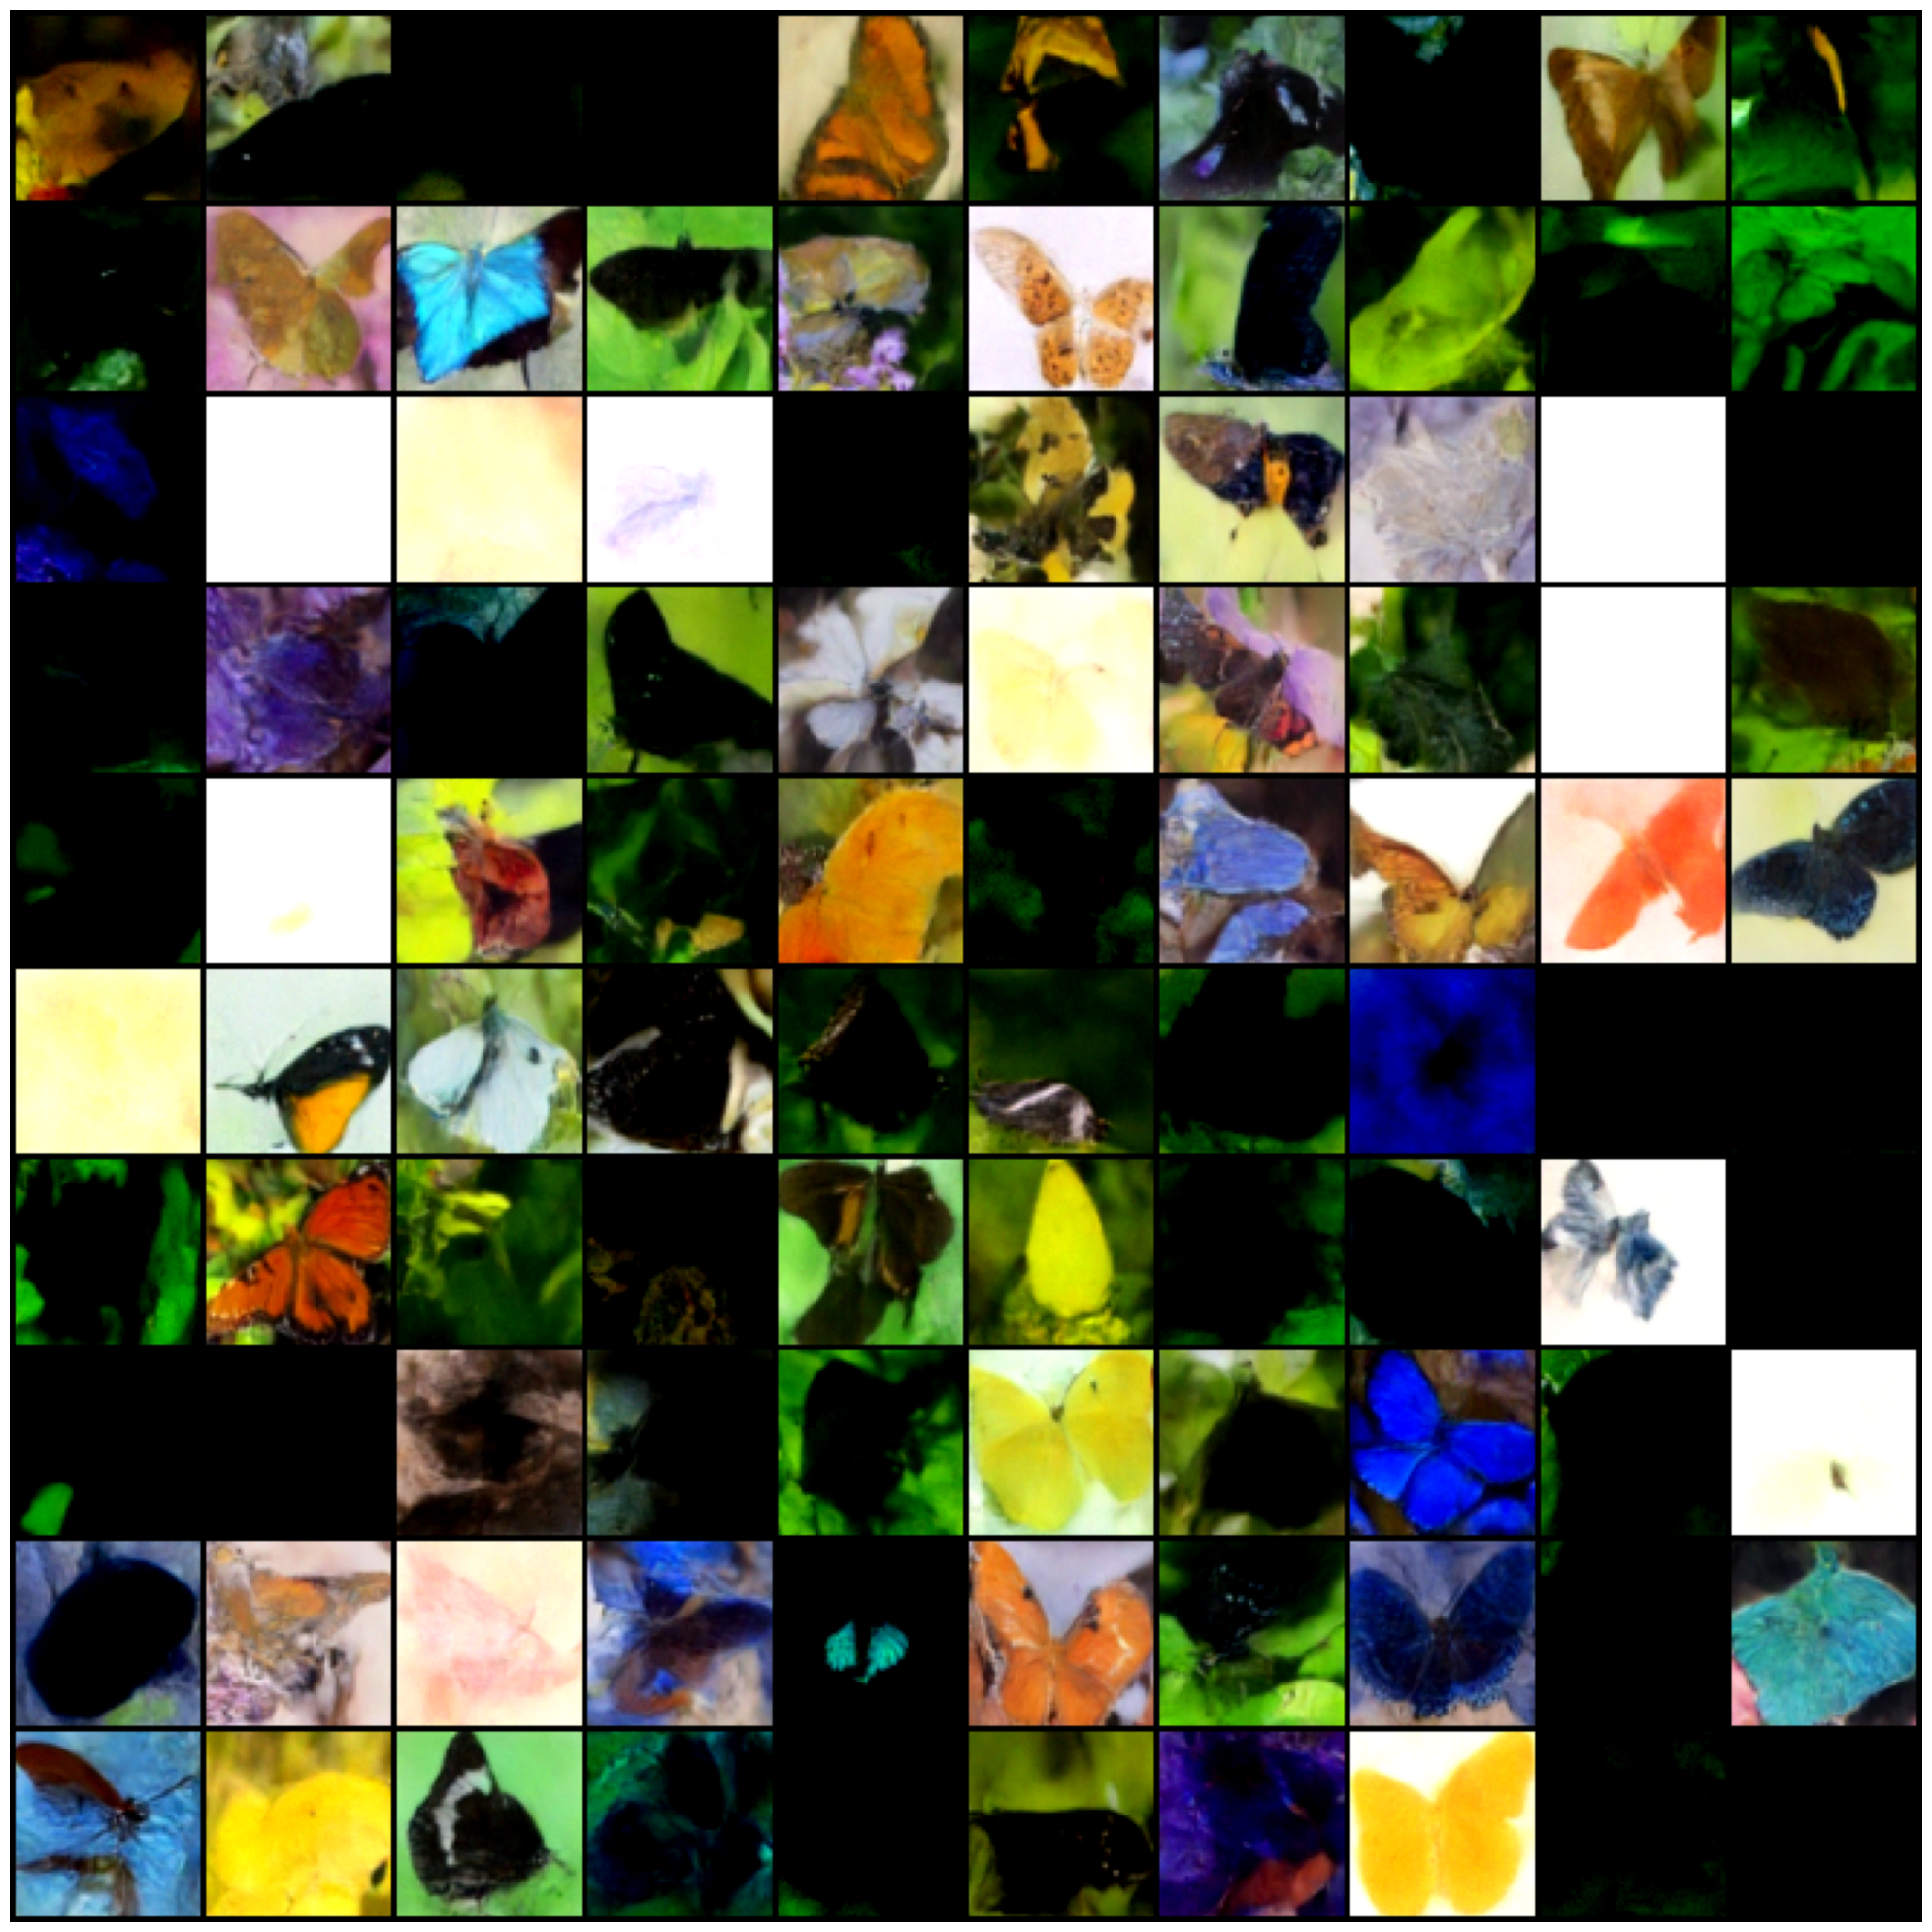

In [6]:
# Sample 100 images for a 10x10 grid
all_images = []
batch_size = 5
total_samples = 100

for i in range(0, total_samples, batch_size):
    n = min(batch_size, total_samples - i)
    print(f"Generating batch {i//batch_size + 1} ({n} images)...")

    # Sample n images
    with torch.no_grad():
        sampled = diffusion.sample(model, n=n)
    
    # Move to CPU to free GPU memory if needed
    sampled = sampled.cpu()

    all_images.append(sampled)

    # Optional: Clear CUDA cache to prevent memory accumulation
    torch.cuda.empty_cache()

# Concatenate all batches into one tensor
sampled_images = torch.cat(all_images, dim=0)


# Convert from uint8 to float for display
if sampled_images.dtype == torch.uint8:
    display_images = sampled_images.float() / 255.0
else:
    display_images = sampled_images

# Create a 10x10 grid
grid = torchvision.utils.make_grid(display_images, nrow=10, normalize=False, padding=2)

# Plot the grid
plt.figure(figsize=(20, 20))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
from utils import load_real_images_for_fid
from metrics import FID

# Load real images
print("Loading real images...")
real_images = load_real_images_for_fid(
    dataset_path=r"data\train",
    image_size=64,
    num_images=1000,
    batch_size=32
)

# Sample 1000 generated images
print("Sampling 1000 generated images...")
all_images = []
batch_size = 5
total_samples = 1000

for i in range(0, total_samples, batch_size):
    n = min(batch_size, total_samples - i)
    print(f"Generating batch {i//batch_size + 1} ({n} images)...")

    # Sample n images safely
    with torch.no_grad():
        sampled = diffusion.sample(model, n=n)

    # Move to CPU immediately to free GPU memory
    sampled = sampled.detach().cpu()

    # Normalize if output is in [-1, 1]
    if sampled.min() < 0:
        sampled = (sampled + 1) / 2.0  # scale to [0,1]

    all_images.append(sampled)

    # Clear GPU memory between batches
    torch.cuda.empty_cache()

# Concatenate all batches into one tensor
generated_images = torch.cat(all_images, dim=0)

# Convert generated images to [-1, 1] range to match real images
if generated_images.dtype == torch.uint8:
    generated_images = generated_images.float() / 255.0  # [0, 1]
    generated_images = generated_images * 2.0 - 1.0  # [-1, 1]


Loading real images...


10:21:41 PM - INFO - Sampling 5 new images.......


Sampling 1000 generated images...
Generating batch 1 (5 images)...


999it [01:17, 12.89it/s]
10:22:59 PM - INFO - Sampling 5 new images.......


Generating batch 2 (5 images)...


...

999it [01:14, 13.40it/s]
02:30:55 AM - INFO - Sampling 5 new images.......


Generating batch 199 (5 images)...


999it [01:14, 13.35it/s]
02:32:10 AM - INFO - Sampling 5 new images.......


Generating batch 200 (5 images)...


999it [01:14, 13.40it/s]


In [8]:
# Compute FID
print("Computing FID score...")
fid_score = FID(real_images, generated_images, device=device, batch_size=50)

print(f"\nFID Score: {fid_score:.2f}")

d:\Tutorials\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Tutorials\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Computing FID score...
Loading Inception v3 model...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:01<00:00, 59.2MB/s] 


Calculating statistics for real images...


Extracting features: 100%|██████████| 20/20 [00:03<00:00,  6.43it/s]


Calculating statistics for generated images...


Extracting features: 100%|██████████| 20/20 [00:02<00:00,  6.75it/s]


Calculating FID score...

FID Score: 161.48


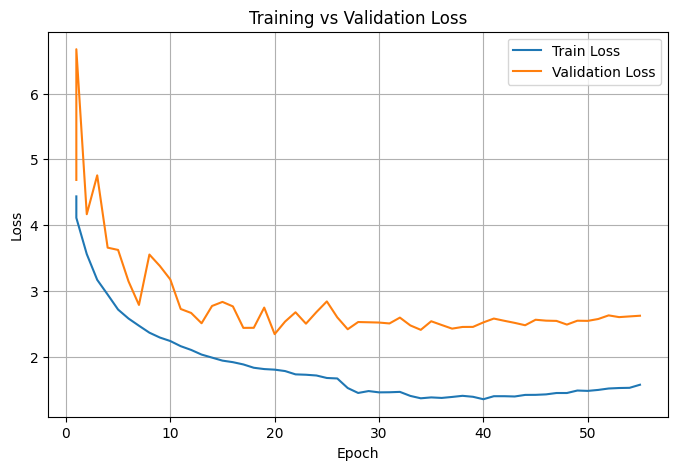

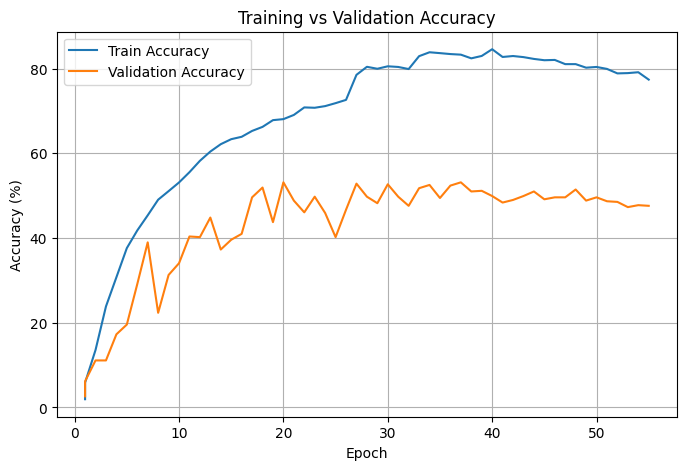

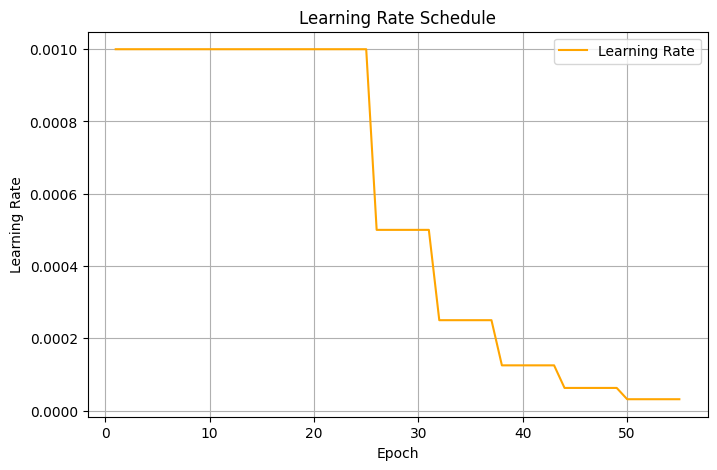

In [14]:
# Plot training and validation loss
import pandas as pd
df=pd.read_csv(r"results\CLASSIFIER\metrics.csv")

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_acc'], label='Train Accuracy')
plt.plot(df['epoch'], df['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot learning rate schedule
plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['lr'], label='Learning Rate', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.show()


Possible reasons for low accuracy and overfitting
1. Smaller resolution of picture 64 X 64 where ResNet is Designed for 244 X 244 
2. Linear Noise Scheduler for the diffusion noise steps.

Can possible improve this by introducing L2 Loss regularisation,
Uplscaling images,
Already added dropout layers to improve it.

In [3]:
image_size = 64
guidance_scale = 1.5  # Adjust as needed
n_samples_per_class = 1  # Number of images per class
with open(class_to_idx_path, 'r') as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"\nGenerating {n_samples_per_class} image(s) per class for {num_classes} classes...")
all_images = []
all_labels = []

for class_idx in tqdm(range(num_classes), desc="Generating images"):
    class_name = idx_to_class.get(class_idx, f"Class_{class_idx}")
    
    # Generate images for this class
    generated_images = diffusion.sample_guided(
        model=model,
        classifier=classifier_model,
        target_class=class_idx,
        n=n_samples_per_class,
        guidance_scale=guidance_scale
    )
    
    # Convert from uint8 [0, 255] to float [0, 1] for plotting
    images_float = generated_images.float() / 255.0
    
    # Store images and labels
    for img in images_float:
        all_images.append(img)
        all_labels.append(f"{class_idx}: {class_name}")

# Convert to tensor for easier handling
all_images_tensor = torch.stack(all_images)

# Create visualization
print("\nCreating visualization...")

# Calculate grid dimensions
n_images = len(all_images)
n_cols = 10  # Number of columns in the grid
n_rows = int(np.ceil(n_images / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx in range(n_cols * n_rows):
    ax = axes[idx]
    if idx < n_images:
        # Display image
        img = all_images_tensor[idx].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img)
        ax.set_title(all_labels[idx], fontsize=8, pad=2)
    else:
        # Hide empty subplots
        ax.axis('off')
    ax.axis('off')

plt.tight_layout()
plt.suptitle(f'Classifier-Guided Diffusion: All {num_classes} Classes (Guidance Scale={guidance_scale})', 
             fontsize=14, y=0.995)
plt.show()

print(f"\nGenerated {n_images} images total!")


Generating 1 image(s) per class for 75 classes...


Generating images:   0%|          | 0/75 [00:00<?, ?it/s]08:26:48 PM - INFO - Sampling 1 new images with classifier guidance (class=0, scale=1.5)...
33it [00:25,  1.27it/s]
Generating images:   0%|          | 0/75 [00:25<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.11 GiB is allocated by PyTorch, and 6.09 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)